# Arpege_hr CSV


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir
from swot import browse_swot_250m, add_mask_inside_swot, build_swath_polygon

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo

crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature


import pyproj
from pyproj import Geod

from rasterio.transform import Affine


_________
# ERA5 data

In [2]:
def E_ggd_from_sigmaN(sigmaN, d=2e3):
    """
    sigmaN : white noise std in cm
    d : grid spacing in m
    """
    from cstes import U2

    sigmaN = sigmaN * 1e-2
    K = -sum(
        np.arange(0, 9)
        * [1 / 280, -4 / 105, 1 / 5, 4 / 5, 0, -4 / 5, -1 / 5, 4 / 105, -1 / 280]
    )
    b = (1 / 280) ** 2 + (4 / 105) ** 2 + (1 / 5) ** 2 + (4 / 5) ** 2
    return 4 / (K**2) / (d**2) * b * (sigmaN**2) / U2


E_ggd_from_sigmaN(0.25)

0.00914407038886298

In [3]:
A = glob('/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/before_coloc/wind/arpege_hr/*.nc')
arpege_hr = xr.open_mfdataset(A)

In [4]:
arpege_hr["f"] = 2 * 2 * np.pi / 86164.1 * np.sin(arpege_hr.latitude * np.pi / 180)


arpege_hr = arpege_hr.sel(
    longitude=slice(0, 15),
    latitude=slice(36, 44),
    time=slice(
        pd.to_datetime("2023-03-01T00:00:00"), pd.to_datetime("2023-07-31T23:00:00")
    ),
)
arpege_hr = arpege_hr.rename({"u10m":"u10", "v10m":"v10"})

arpege_hr["u10"] = arpege_hr["u10"].assign_attrs(
    {"long_name": r"Zonal wind velocity at 10m $u_{10}$", "units": "m/s"}
)
arpege_hr["v10"] = arpege_hr["v10"].assign_attrs(
    {"long_name": r"Meridional wind velocity at 10m $v_{10}$", "units": "m/s"}
)

In [5]:
def stress_from_velocity(ds):
    """
    taue = rho * Cd * U *u with Cd = 0.008 +0.008*U10
    see  https://confluence.ecmwf.int/display/CKB/ERA5%3A+data+documentation#ERA5:datadocumentation-Instantaneousparameters in The instantaneous turbulent surface stress components (eastward and northward) and friction velocity tend to be too small
    """

    rho = 1.204  # 20C
    Cd = 0.0015 
    U = np.sqrt(ds["u10"] ** 2 + ds["v10"] ** 2)
    #Cd = (2.7 / U + 0.142 + 0.0764 * U) / 1e3
    #Cd =  (0.008 + 0.0008* U)
    # print(Cd(U))
    ds["iews"] = rho * Cd * U * ds["u10"]  # *1e6
    ds["inss"] = rho * Cd * U * ds["v10"]  # *1e6

stress_from_velocity(arpege_hr)


In [6]:
def add_ekman_rio(arpege_hr, z) : 
    # Ekman rio
    if z == 0:
        theta0 = -22.5 * np.pi / 180 * np.sign(arpege_hr.f)
        beta0 = 0.6
        arpege_hr["ue_rioold"] = (
            beta0 * (np.cos(theta0) * arpege_hr.iews - np.sin(theta0) * arpege_hr.inss)
        ).assign_attrs({"long_name": r"Zonal Rio $u_{Ekman}$", "units": "m/s"})
        arpege_hr["ve_rioold"] = (
            beta0 * (np.sin(theta0) * arpege_hr.iews + np.cos(theta0) * arpege_hr.inss)
        ).assign_attrs({"long_name": r"Meridional Rio $v_{Ekman}$", "units": "m/s"})

        theta0 = -30 * np.pi / 180 * np.sign(arpege_hr.f)
        beta0 = 1.05
        arpege_hr["ue_rio"] = (
            beta0 * (np.cos(theta0) * arpege_hr.iews - np.sin(theta0) * arpege_hr.inss)
        ).assign_attrs({"long_name": r"Zonal updated Rio $u_{Ekman}$", "units": "m/s"})
        arpege_hr["ve_rio"] = (
            beta0 * (np.sin(theta0) * arpege_hr.iews + np.cos(theta0) * arpege_hr.inss)
        ).assign_attrs(
            {"long_name": r"Meridional updated Rio $v_{Ekman}$", "units": "m/s"}
        )

    if z == -15:
        theta15 = -37.5 * np.pi / 180 * np.sign(arpege_hr.f)  # adapted for mediterranean sea
        beta15 = 0.15
        arpege_hr["ue_rioold"] = (
            beta15 * (np.cos(theta15) * arpege_hr.iews - np.sin(theta15) * arpege_hr.inss)
        ).assign_attrs({"long_name": r"Zonal Rio $u_{Ekman}$", "units": "m/s"})
        arpege_hr["ve_rioold"] = (
            beta15 * (np.sin(theta15) * arpege_hr.iews + np.cos(theta15) * arpege_hr.inss)
        ).assign_attrs({"long_name": r"Meridional Rio $v_{Ekman}$", "units": "m/s"})

        theta15 = -57 * np.pi / 180 * np.sign(arpege_hr.f)  # adapted for mediterranean sea
        beta15 = 0.32
        arpege_hr["ue_rio"] = (
            beta15 * (np.cos(theta15) * arpege_hr.iews - np.sin(theta15) * arpege_hr.inss)
        ).assign_attrs({"long_name": r"Zonal updated Rio $u_{Ekman}$", "units": "m/s"})
        arpege_hr["ve_rio"] = (
            beta15 * (np.sin(theta15) * arpege_hr.iews + np.cos(theta15) * arpege_hr.inss)
        ).assign_attrs(
            {"long_name": r"Meridional updated Rio $v_{Ekman}$", "units": "m/s"}
        )

    # Vertical turbulent Stress divergence
    arpege_hr["vsde_rio"] = arpege_hr.f * (arpege_hr.ve_rio).assign_attrs(
        {"long_name": r"Zonal updated Rio VSD", "units": r"$m.s^{-2}$"}
    )
    arpege_hr["vsdn_rio"] = -arpege_hr.f * (arpege_hr.ue_rio).assign_attrs(
        {"long_name": r"Meridional updated Rio VSD", "units": r"$m.s^{-2}$"}
    )

    # Vertical turbulent Stress divergence
    arpege_hr["vsde_rioold"] = arpege_hr.f * (arpege_hr.ve_rioold).assign_attrs(
        {"long_name": r"Zonal updated Rio VSD", "units": r"$m.s^{-2}$"}
    )
    arpege_hr["vsdn_rioold"] = -arpege_hr.f * (arpege_hr.ue_rioold).assign_attrs(
        {"long_name": r"Meridional updated Rio VSD", "units": r"$m.s^{-2}$"}
    )

    return arpege_hr
    
arpege_hr_0 = add_ekman_rio(arpege_hr, z=0)
arpege_hr_15 = add_ekman_rio(arpege_hr, z=1)

In [7]:
arpege_hr_0 = arpege_hr_0.rename({v : v +'_z0' for v in [v for v in arpege_hr_0 if ('ue' in v)|('ve' in v)|('vsd' in v)]})
arpege_hr_15 = arpege_hr_15.rename({v : v +'_z15' for v in [v for v in arpege_hr_15 if ('ue' in v)|('ve' in v)|('vsd' in v)]})

In [8]:
era0 = xr.open_dataset(os.path.join(zarr_dir, "before_coloc", "wind", "era5_agesc_rio_z0.nc"))
era15 = xr.open_dataset(os.path.join(zarr_dir, "before_coloc", "wind", "era5_agesc_rio_z15.nc"))

In [9]:
ad0 = arpege_hr_0.resample(time="1D").mean('time')
ad15 = arpege_hr_15.resample(time="1D").mean('time')


KeyboardInterrupt



/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.scheduler.transition-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.comm.recent-messages-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(


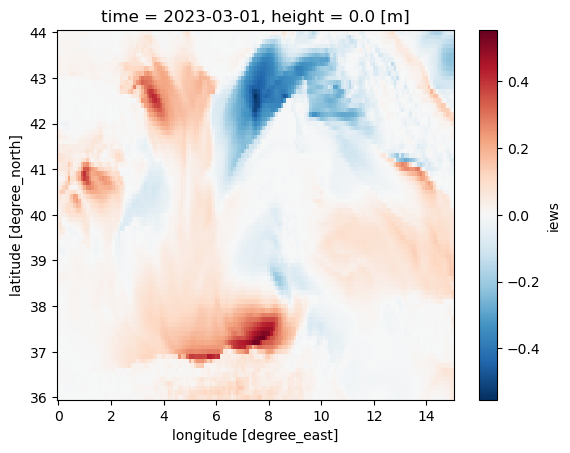

In [10]:
arpege_hr_0.isel(time=0).iews.plot()

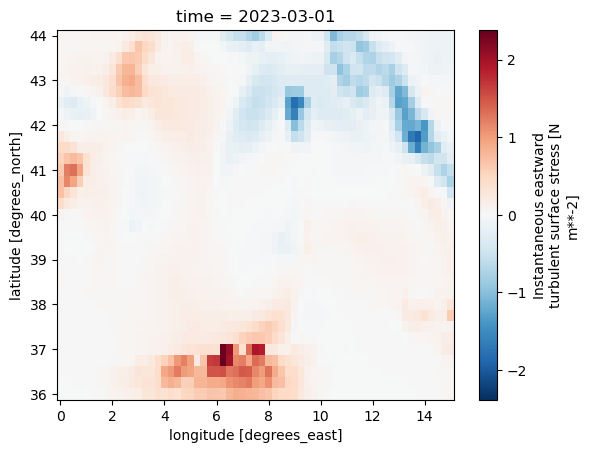

In [11]:
era0.isel(time=0).iews.plot()

In [44]:
arpege_hr

<xarray.Dataset> Size: 3GB
Dimensions:      (time: 3672, latitude: 81, longitude: 151)
Coordinates:
  * time         (time) datetime64[ns] 29kB 2023-03-01 ... 2023-07-31T23:00:00
  * latitude     (latitude) float32 324B 36.0 36.1 36.2 36.3 ... 43.8 43.9 44.0
  * longitude    (longitude) float32 604B 0.0 0.1 0.2 0.3 ... 14.8 14.9 15.0
    height       float32 4B 0.0
Data variables: (12/17)
    hu2m         (time, latitude, longitude) float32 180MB dask.array<chunksize=(24, 81, 151), meta=np.ndarray>
    nebul        (time, latitude, longitude) float32 180MB dask.array<chunksize=(24, 81, 151), meta=np.ndarray>
    pmer         (time, latitude, longitude) float32 180MB dask.array<chunksize=(24, 81, 151), meta=np.ndarray>
    t2m          (time, latitude, longitude) float32 180MB dask.array<chunksize=(24, 81, 151), meta=np.ndarray>
    u10          (time, latitude, longitude) float32 180MB dask.array<chunksize=(24, 81, 151), meta=np.ndarray>
    v10          (time, latitude, longitude) float32 180MB dask.array<chunksize=(24, 81, 151), meta=np.ndarray>
    ...           ...
    ue_rio       (latitude, time, longitude) float32 180MB dask.array<chunksize=(81, 24, 151), meta=np.ndarray>
    ve_rio       (latitude, time, longitude) float32 180MB dask.array<chunksize=(81, 24, 151), meta=np.ndarray>
    vsde_rio     (latitude, time, longitude) float32 180MB dask.array<chunksize=(81, 24, 151), meta=np.ndarray>
    vsdn_rio     (latitude, time, longitude) float32 180MB dask.array<chunksize=(81, 24, 151), meta=np.ndarray>
    vsde_rioold  (latitude, time, longitude) float32 180MB dask.array<chunksize=(81, 24, 151), meta=np.ndarray>
    vsdn_rioold  (latitude, time, longitude) float32 180MB dask.array<chunksize=(81, 24, 151), meta=np.ndarray>
Attributes: (12/40)
    data_type:               OCO straight grid
    format_version:          1.2
    title:                   Meteo-France Arpege forecast and analysis
    Conventions:             CF-1.3
    netcdf_version:          3.5
    product_name:            METEOFRANCE_ARPEGE-HR_20230101T00Z.nc
    ...                      ...
    data_centre:             CD-OCO
    data_centre_references:  http://www.previmer.org/
    contact:                 cdoco-exploit@ifremer.fr
    distribution_statement:  Data restrictions: for registered users only
    operational_status:      operational
    quality_index:           1

In [12]:
ad0.isel(time=0).iews.plot()

NameError: name 'ad0' is not defined

# Interp on 

In [13]:
era5 = xr.merge([era0, era15]).sortby("latitude").compute()
arp = xr.merge([arpege_hr_0, arpege_hr_15]).sortby("latitude").compute()

In [14]:
# TO CHOOSE
drifters_sources = "all_med_variational_10min_v1.nc"

# Drifters param
dt = "12h"
drifter_preprocess = "spectral_decomp"  # '', 'spectral_decomp', 'low_pass'

if drifter_preprocess == True:
    drifters_sources = "spectral_decomp_" + drifters_sources

colocs_source = f"{dt}_{drifter_preprocess}_{drifters_sources}"

# Drifters
df = (
    pd.read_csv(
        os.path.join(
            zarr_dir,
            "coloc_files",
            "drifters",
            f"drifterscoloc_" + colocs_source.replace(".nc", ".csv"),
        ),
        dtype={"drifter_id": str},
        parse_dates=["datetime"],
    )
    .set_index("row_number")
)

In [15]:
lon = df.longitude.values
lat = df.latitude.values
t = pd.to_datetime(df.datetime).values
dse = era5.interp(longitude=("z", lon), latitude=("z", lat), time=("z", t))
print("interp_ok")
dfe = dse.to_dataframe()
dfe.index.names = ["row_number"]

dsa = arp.interp(longitude=("z", lon), latitude=("z", lat), time=("z", t))
print("interp_ok")
dfa = dsa.to_dataframe()
dfa.index.names = ["row_number"]

interp_ok
interp_ok


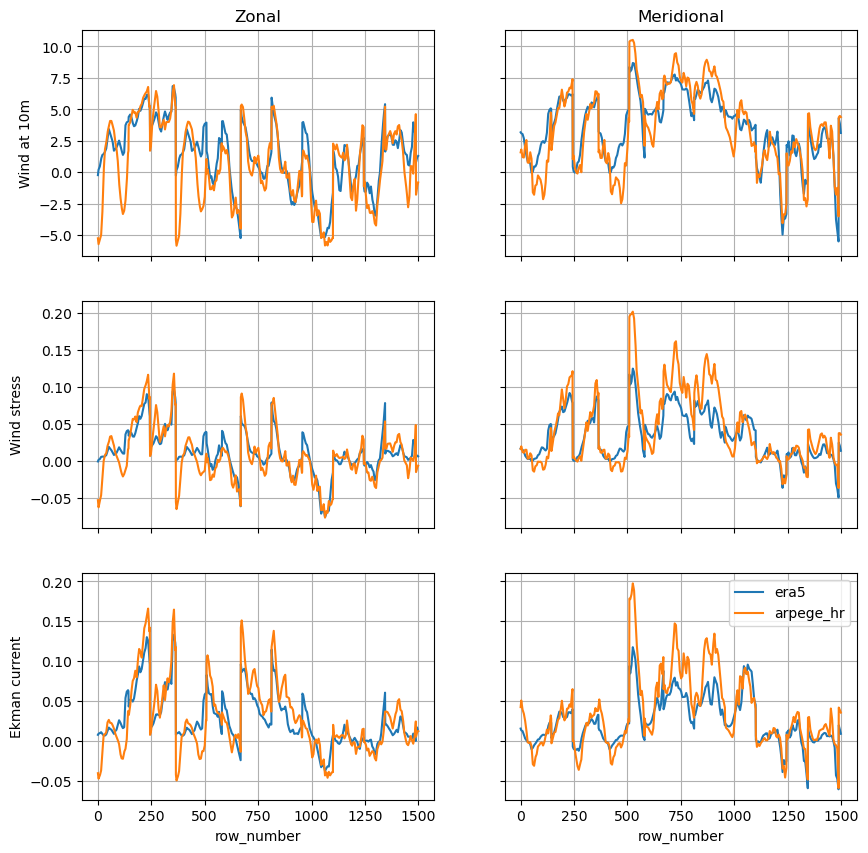

In [20]:
dfe_ = dfe.iloc[:1500]
dfa_ = dfa.iloc[:1500]

fig, axs = plt.subplots(3, 2, figsize=(10,10), sharey = 'row', sharex=True)
axs=axs.flatten()

ax= axs[0]
dfe_.u10.plot(ax = ax, label='era5')
dfa_.u10.plot(ax = ax,label='arpege_hr')
ax.set_ylabel('Wind at 10m')
ax.set_title('Zonal')

ax= axs[1]
dfe_.v10.plot(ax = ax, label='era5')
dfa_.v10.plot(ax = ax,label='arpege_hr')
ax.set_title('Meridional')

ax= axs[2]
dfe_.iews.plot(ax = ax, label='era5')
dfa_.iews.plot(ax = ax,label='arpege_hr')
ax.set_ylabel('Wind stress')

ax= axs[3]
dfe_.inss.plot(ax = ax, label='era5')
dfa_.inss.plot(ax = ax,label='arpege_hr')


ax= axs[4]
dfe_.ue_rio_z0.plot(ax = ax, label='era5')
dfa_.ue_rio_z0.plot(ax = ax,label='arpege_hr')
ax.set_ylabel('Ekman current')

ax= axs[5]
dfe_.ve_rio_z0.plot(ax = ax, label='era5')
dfa_.ve_rio_z0.plot(ax = ax,label='arpege_hr')


ax.legend()

for ax in axs :
    ax.grid()

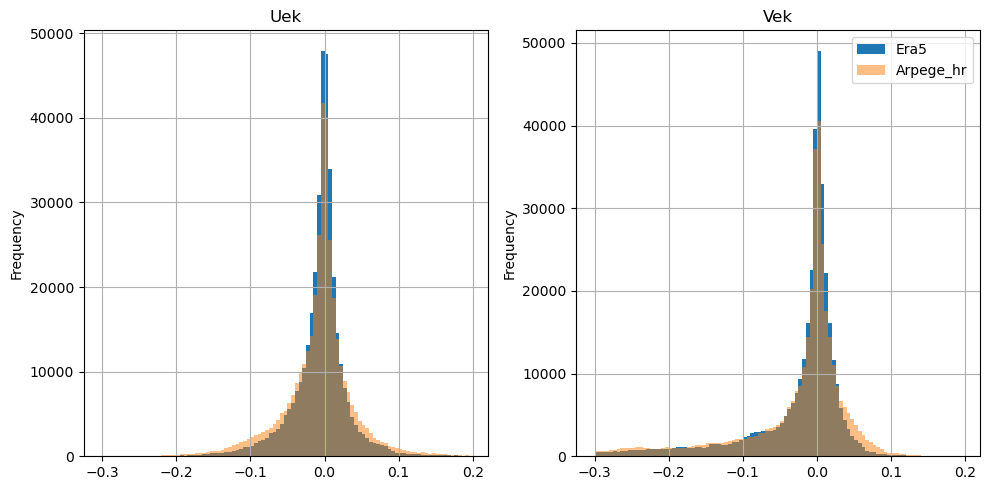

In [45]:
fig, axs = plt.subplots(1,2, figsize=(10,5))
ax=axs[0]
dfe.ue_rio_z0.plot.hist(ax=ax, label = 'Era5', bins = np.arange(-0.3, 0.2, 5e-3))
dfa.ue_rio_z0.plot.hist(ax=ax, label = 'Arpege_hr', bins = np.arange(-0.3, 0.2, 5e-3), alpha=0.5)
ax.set_title('Uek')
ax=axs[1]
dfe.ve_rio_z0.plot.hist(ax=ax, label = 'Era5', bins = np.arange(-0.3, 0.2, 5e-3))
dfa.ve_rio_z0.plot.hist(ax=ax, label = 'Arpege_hr', bins = np.arange(-0.3, 0.2, 5e-3), alpha=0.5)
ax.set_title('Vek')
ax.legend()
for ax in axs: 
    ax.grid()
fig.tight_layout()

In [42]:
wd_product_key = 'arpege'
wd_model = 'rioagesc'

dfa.to_csv(os.path.join(
            zarr_dir,
            "coloc_files",
            "wind",
            f"{wd_product_key}_{wd_model}_" + colocs_source.replace(".nc", "") + ".csv",
        ))